In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from pangya_physics import (
    CLUBS,
    Ball,
    PangyaSimulator,
    Vector3D,
    Wind,
)
from pangya_physics.solver import create_initial_velocity

In [2]:
def simulate_club(
    club_name,
    power_percent=1.0,
):
    club = CLUBS[club_name]

    ball = Ball(
        velocity=create_initial_velocity(
            club=club,
            power_percent=power_percent,
        )
    )

    simulator = PangyaSimulator(
        ball=ball,
        club=club,
        wind=Wind(speed=0, degree=0),
    )

    for _ in range(5000):
        simulator.step()

        if simulator.ball.position.y < 0 and simulator.ball.count > 10:
            break

    return {
        "club": club_name,
        "distance": simulator.ball.position.z,
        "max_height": simulator.ball.max_height,
        "flight_steps": simulator.ball.count,
    }

In [3]:
results = []

for club_name in CLUBS.keys():
    results.append(
        simulate_club(
            club_name,
            power_percent=1.0,
        )
    )

df_clubs = pd.DataFrame(results)

df_clubs

,club,distance,max_height,flight_steps
0,1W,348.470713,18.506741,104
1,2W,338.381296,23.452872,117
2,3W,314.588992,26.753009,125
3,2I,316.060393,34.354210,141
4,3I,314.117281,41.606154,156
5,4I,306.111441,48.355464,168
6,5I,296.524395,54.881494,179
7,6I,283.293298,60.763896,188
8,7I,268.356404,66.149699,196
9,8I,255.832702,72.250994,205


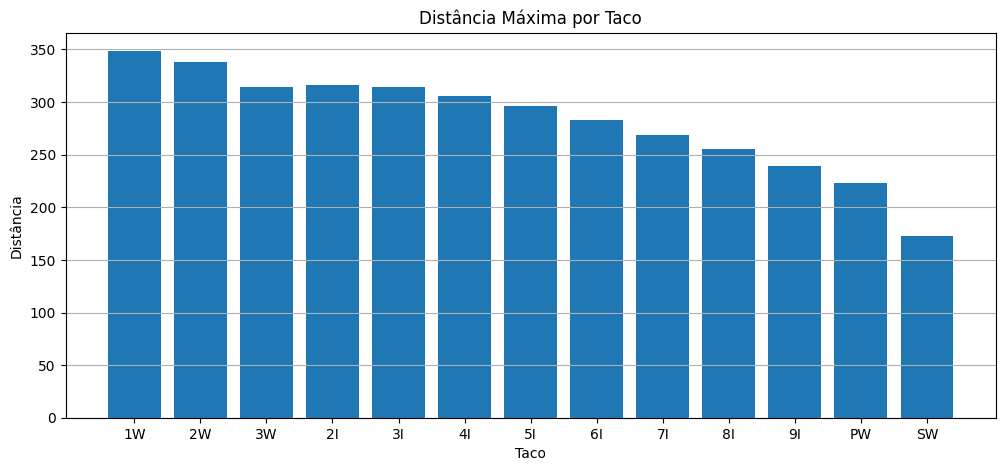

In [4]:
plt.figure(figsize=(12, 5))

plt.bar(
    df_clubs["club"],
    df_clubs["distance"],
)

plt.title("Distância Máxima por Taco")
plt.xlabel("Taco")
plt.ylabel("Distância")

plt.grid(axis="y")

plt.show()

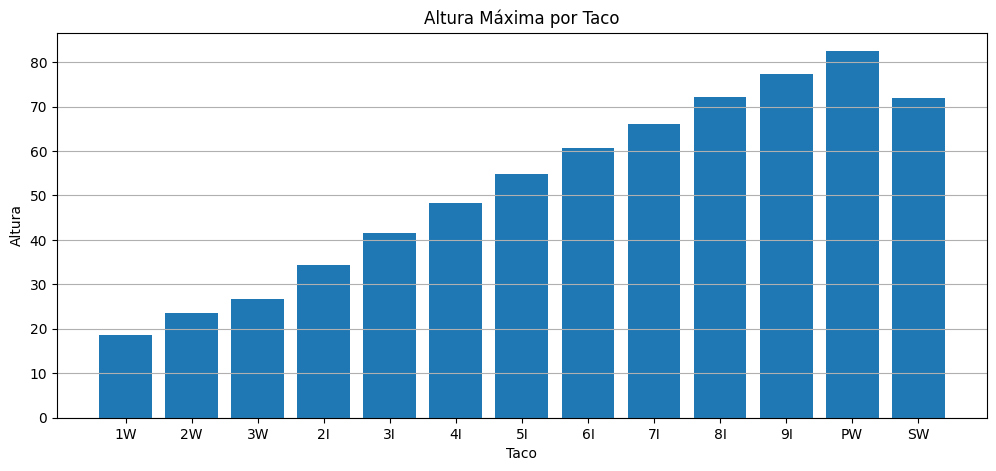

In [5]:
plt.figure(figsize=(12, 5))

plt.bar(
    df_clubs["club"],
    df_clubs["max_height"],
)

plt.title("Altura Máxima por Taco")
plt.xlabel("Taco")
plt.ylabel("Altura")

plt.grid(axis="y")

plt.show()

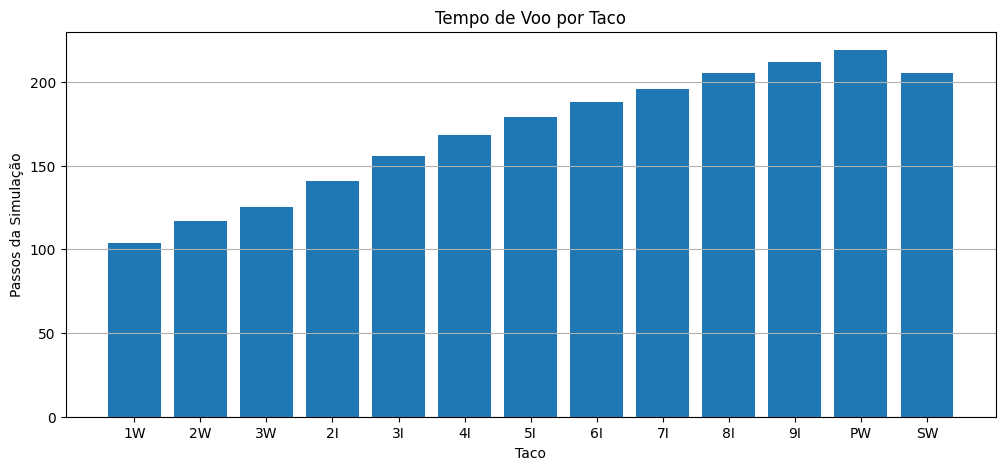

In [6]:
plt.figure(figsize=(12, 5))

plt.bar(
    df_clubs["club"],
    df_clubs["flight_steps"],
)

plt.title("Tempo de Voo por Taco")
plt.xlabel("Taco")
plt.ylabel("Passos da Simulação")

plt.grid(axis="y")

plt.show()

In [7]:
ranking = (
    df_clubs
    .sort_values(
        by="distance",
        ascending=False,
    )
    .reset_index(drop=True)
)

ranking

,club,distance,max_height,flight_steps
0,1W,348.470713,18.506741,104
1,2W,338.381296,23.452872,117
2,2I,316.060393,34.354210,141
3,3W,314.588992,26.753009,125
4,3I,314.117281,41.606154,156
5,4I,306.111441,48.355464,168
6,5I,296.524395,54.881494,179
7,6I,283.293298,60.763896,188
8,7I,268.356404,66.149699,196
9,8I,255.832702,72.250994,205
